In [1]:
#installing dependences and loading data

In [1]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np

In [3]:
os.path.join('data','train.csv')

'data\\train.csv'

In [2]:
df = pd.read_csv(os.path.join('data','train.csv'))

In [3]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.iloc[2]['comment_text']

"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."

In [5]:
df[df['toxic']==1].head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
12,0005c987bdfc9d4b,Hey... what is it..\n@ | talk .\nWhat is it......,1,0,0,0,0,0
16,0007e25b2121310b,"Bye! \n\nDon't look, come or think of comming ...",1,0,0,0,0,0
42,001810bf8c45bf5f,You are gay or antisemmitian? \n\nArchangel WH...,1,0,1,0,1,1
43,00190820581d90ce,"FUCK YOUR FILTHY MOTHER IN THE ASS, DRY!",1,0,1,0,1,0


In [6]:
df[df.columns[2:]].iloc[5]

toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
Name: 5, dtype: int64

In [7]:
#1 preprocess
from tensorflow.keras.layers import TextVectorization

In [8]:
x = df['comment_text']
y = df[df.columns[2:]].values

In [9]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [10]:
df[df.columns[2:]].values

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], dtype=int64)

In [11]:
MAX_FEATURES = 20000 # number of words in the vocab

In [12]:
vectorizer = TextVectorization(max_tokens = MAX_FEATURES, output_sequence_length = 1800, output_mode = 'int')

In [13]:
vectorizer.adapt(x.values)

In [14]:
vectorizer('hello world,life is great')

<tf.Tensor: shape=(1800,), dtype=int64, numpy=array([286,   1,   9, ...,   0,   0,   0], dtype=int64)>

In [15]:
vectorized_text = vectorizer(x.values)

In [16]:
vectorized_text

<tf.Tensor: shape=(159571, 1800), dtype=int64, numpy=
array([[ 643,   76,    2, ...,    0,    0,    0],
       [   1,   54, 2506, ...,    0,    0,    0],
       [ 425,  440,   70, ...,    0,    0,    0],
       ...,
       [   1, 7329,  383, ...,    0,    0,    0],
       [   5,   12,  533, ...,    0,    0,    0],
       [   5,    8,  130, ...,    0,    0,    0]], dtype=int64)>

In [17]:
#tensflow data pipeline
#MCSHBAP- map, chache, shuffle, batch, prefetch from_tensor_slices, list_file


dataset = tf.data.Dataset.from_tensor_slices((vectorized_text,y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset =dataset.batch(16)
dataset = dataset.prefetch(8)


In [18]:
batch_x, batch_y = dataset.as_numpy_iterator().next()

In [19]:
batch_x.shape

(16, 1800)

In [20]:
batch_y.shape

(16, 6)

In [21]:
int(len(dataset)*.7)

6981

In [22]:
train = dataset.take(int(len(dataset)*.7))
val = dataset.skip(int(len(dataset)*.7)).take(int(len(dataset)*.2))
test = dataset.skip(int(len(dataset)*.9)).take(int(len(dataset)*.1))

In [23]:
train_generator = train.as_numpy_iterator()

In [24]:
train_generator.next()

(array([[   1,    1,   70, ...,    0,    0,    0],
        [8589, 7500,   20, ...,    0,    0,    0],
        [   8,   44, 1799, ...,    0,    0,    0],
        ...,
        [ 360,   14,   59, ...,    0,    0,    0],
        [   5,   18,    6, ...,    0,    0,    0],
        [   1,    1,  425, ...,    0,    0,    0]], dtype=int64),
 array([[0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]], dtype=int64))

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Bidirectional, Dense, Embedding

In [26]:
model = Sequential()
model.add(Embedding(MAX_FEATURES+1,32))

model.add(Bidirectional(LSTM(32,activation = 'tanh')))

model.add(Dense(128, activation = 'relu'))
model.add(Dense(256, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))
#final layer
model.add(Dense(6, activation = 'sigmoid'))
#turns value to between 0 to 1


In [27]:
model.compile(loss = 'BinaryCrossentropy', optimizer = 'Adam')

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 32)          640032    
                                                                 
 bidirectional (Bidirectiona  (None, 64)               16640     
 l)                                                              
                                                                 
 dense (Dense)               (None, 128)               8320      
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 6)                 774       
                                                        

In [29]:
history = model.fit(train, epochs = 5, validation_data = val)

Epoch 1/5
6981/6981 [==============================] - 2093s 299ms/step - loss: 0.0648 - val_loss: 0.0499
Epoch 2/5
6981/6981 [==============================] - 2317s 332ms/step - loss: 0.0488 - val_loss: 0.0444
Epoch 3/5
6981/6981 [==============================] - 2046s 293ms/step - loss: 0.0444 - val_loss: 0.0411
Epoch 4/5
6981/6981 [==============================] - 2086s 299ms/step - loss: 0.0407 - val_loss: 0.0383
Epoch 5/5
6981/6981 [==============================] - 2035s 291ms/step - loss: 0.0384 - val_loss: 0.0364


In [30]:
import tensorflow as tf

# create wrapper model
vectorizer_model = tf.keras.Sequential([vectorizer])

# save it
vectorizer_model.save("vectorizer_model")

INFO:tensorflow:Assets written to: vectorizer_model\assets


In [32]:
from matplotlib import pyplot as plt

<Figure size 900x600 with 0 Axes>

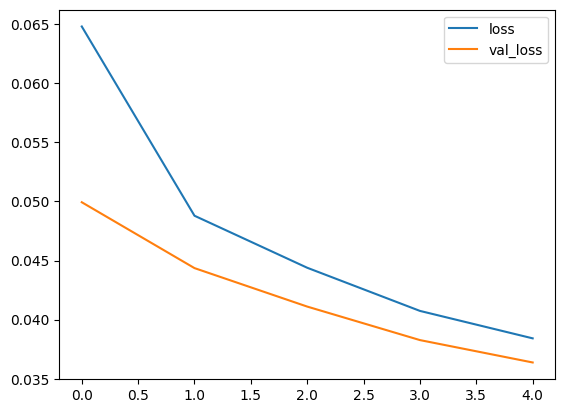

In [33]:
plt.figure(figsize=(9,6))
pd.DataFrame(history.history).plot()
plt.show()

In [34]:
history.history

{'loss': [0.06479255855083466,
  0.04878673702478409,
  0.044387344270944595,
  0.04073835536837578,
  0.03841729834675789],
 'val_loss': [0.049928802996873856,
  0.04435791075229645,
  0.041104014962911606,
  0.038270339369773865,
  0.036377087235450745]}

In [35]:
#making predication

input_text =  vectorizer('you freaking suck!')


In [36]:
df.columns[2:]

Index(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')

In [37]:
batch = test.as_numpy_iterator().next()

In [38]:
batch_x,batch_y = test.as_numpy_iterator().next()

In [39]:
(model.predict(batch_x) > 0.5). astype(int)

1/1 [==============================] - 1s 877ms/step


array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0]])

In [40]:
res = model.predict(np.expand_dims(input_text,0))

1/1 [==============================] - 0s 156ms/step


In [41]:
# Evaluate model
from tensorflow.keras.metrics import Precision, Recall , CategoricalAccuracy

In [42]:
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()

In [43]:
for batch in test.as_numpy_iterator():
    x_true, y_true = batch
    yhat = model.predict(x_true)
    y_true = y_true.flatten()
    yhat = yhat.flatten()

    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true,yhat)

1/1 [==============================] - 0s 119ms/step


In [44]:
print(f'Precision: {pre.result().numpy()},Recall:{re.result().numpy()},Accuracy:{acc.result().numpy()}')

Precision: 0.8669841289520264,Recall:0.7533792853355408,Accuracy:0.5065195560455322


In [45]:

model.save('models/toxicity.h5')
